In [1]:
pip install pandas numpy scikit-learn nltk


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import string

In [5]:
import nltk

In [6]:
from nltk.corpus import stopwords

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
from sklearn.naive_bayes import MultinomialNB

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vanshikasharma/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
df = pd.read_csv('data/spamData.csv')

In [14]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [15]:
df.columns
df['label'].unique()

array([1, 0])

In [16]:

df = df[['text','label']]

In [17]:
df.columns = ['message','label']

In [18]:
def clean_text(text):

    text = text.lower()

    return text

In [19]:
df['message'] = df['message'].apply(clean_text)

In [20]:
vectorizer = TfidfVectorizer()

In [21]:
X = vectorizer.fit_transform(df['message'])

In [22]:
y = df['label']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model=MultinomialNB()

In [25]:
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9768723786698622


In [28]:
pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

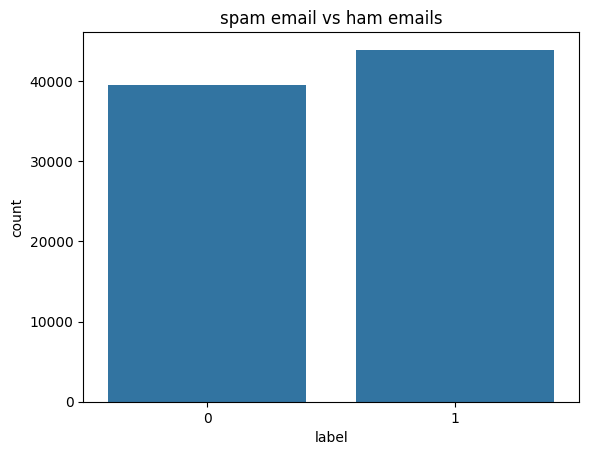

In [30]:
sns.countplot(x=df['label'])
plt.title("spam email vs ham emails")
plt.show()

In [31]:
df['label_name'] = df['label'].map({
    0:'Ham',
    1:'Spam'
})

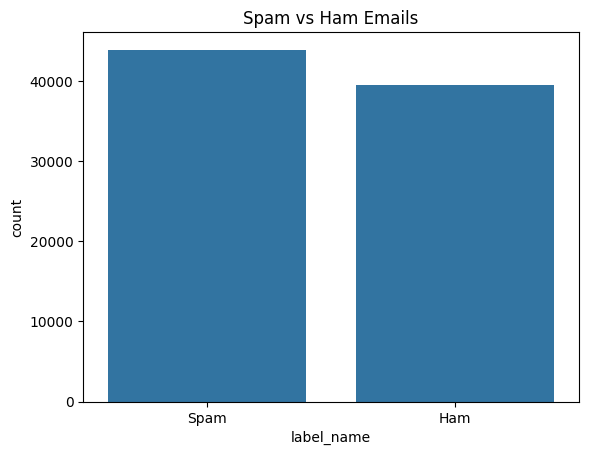

In [32]:
sns.countplot(x=df['label_name'])
plt.title("Spam vs Ham Emails")
plt.show()

In [33]:
df['email_length'] = df['message'].apply(len)

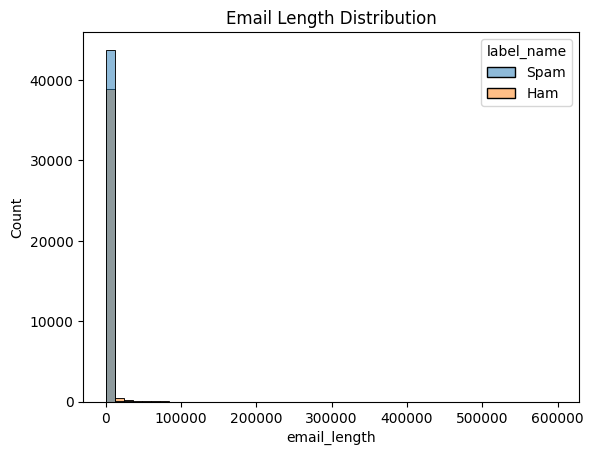

In [34]:
sns.histplot(
    data=df,
    x='email_length',
    hue='label_name',
    bins=50
)
plt.title("Email Length Distribution")
plt.show()

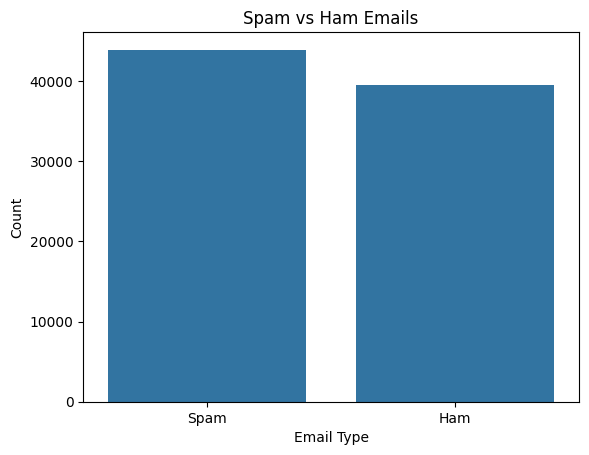

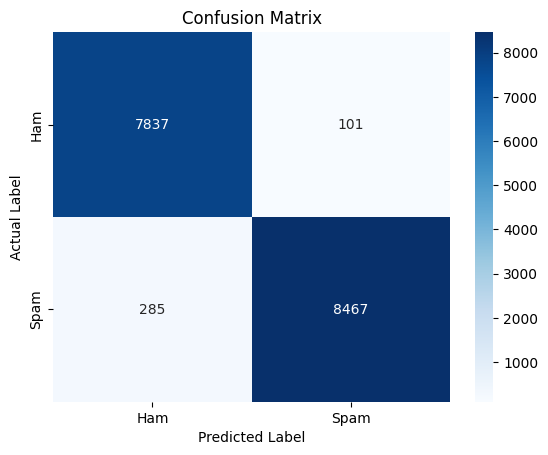

In [35]:


from sklearn.metrics import confusion_matrix

#DATASET  GRAPH

# convert numeric labels into readable names
df['label_name'] = df['label'].map({
    0: 'Ham',
    1: 'Spam'
})

# create graph
sns.countplot(x=df['label_name'])
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")

# show graph
plt.show()


# MODEL PREDICTION GRAPH


#confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# show graph
plt.show()

In [36]:
import pickle
pickle.dump(model, open('spam_model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))